# Lab 4 - Frequent Patterns + Neural Models (Pima Diabetes)

## Mục tiêu
- Dùng cùng bộ dữ liệu như Lab 3 (Pima Indians Diabetes).
- So sánh 3 phương pháp khai phá mẫu phổ biến: Apriori, FP-Growth, ECLAT.
- Xây dựng 2 mô hình học sâu/tabular: Backpropagation MLP và Transfer Learning MLP.
- Đánh giá đầy đủ theo kiểu Lab 3: Confusion Matrix, Accuracy, Precision, Recall, F1-Score, AUC, ROC cho Hold-out 70/30 và 10-Fold CV.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)

# --- CẤU HÌNH TOÀN CỤC ---
KAGGLE_DATASET_REF = "uciml/pima-indians-diabetes-database"
DATA_PATH = "../Lab3/diabetes.csv"
FALLBACK_DATA_URL = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
TARGET_COL = "Outcome"

TEST_SIZE = 0.3
K_FOLDS = 10
RANDOM_STATE = 42

# Cấu hình cho frequent pattern
N_BINS = 4
MIN_SUPPORT = 0.15
MIN_CONFIDENCE = 0.55

# Cấu trúc lưu kết quả
results_list = []
roc_data = {}

In [2]:
# 1) Tải dữ liệu giống Lab 3
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Da doc du lieu local: {DATA_PATH}")
except FileNotFoundError:
    df = pd.read_csv(FALLBACK_DATA_URL)
    print("Khong tim thay file local, dung fallback URL.")

print(f"Kich thuoc bo du lieu: {df.shape}")
print(df[TARGET_COL].value_counts())

X = df.drop(columns=[TARGET_COL]).reset_index(drop=True)
y = df[TARGET_COL].astype(int).reset_index(drop=True)

# Chia hold-out 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

def build_transaction_df(X_num, binner, fit=False):
    X_num = X_num.reset_index(drop=True)
    binned = binner.fit_transform(X_num) if fit else binner.transform(X_num)
    binned = binned.astype(int)

    tx_cat = pd.DataFrame(index=X_num.index)
    for j, col in enumerate(X_num.columns):
        tx_cat[col] = [f"{col}_bin{val}" for val in binned[:, j]]

    tx_onehot = pd.get_dummies(tx_cat, prefix="", prefix_sep="").astype(bool)
    return tx_onehot

def add_outcome_items(tx_onehot, y_true):
    tx = tx_onehot.copy()
    y_true = y_true.reset_index(drop=True)
    tx["Outcome_1"] = (y_true.values == 1)
    tx["Outcome_0"] = (y_true.values == 0)
    return tx

Khong tim thay file local, dung fallback URL.
Kich thuoc bo du lieu: (768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


In [3]:
# 2) Frequent pattern mining: Apriori / FP-Growth / ECLAT
OUTCOME_ITEMS = {"Outcome_0", "Outcome_1"}

def eclat_frequent_itemsets(transactions_bool, min_support=0.15):
    n_tx = len(transactions_bool)
    if n_tx == 0:
        return pd.DataFrame(columns=["support", "itemsets"])

    tidsets = {
        item: set(transactions_bool.index[transactions_bool[item]])
        for item in transactions_bool.columns
    }

    init_items = []
    for item, tids in tidsets.items():
        supp = len(tids) / n_tx
        if supp >= min_support:
            init_items.append((item, tids))
    init_items = sorted(init_items, key=lambda x: x[0])

    freq_records = []

    def recurse(prefix, items_local):
        for i, (item, tids) in enumerate(items_local):
            new_prefix = prefix + [item]
            supp = len(tids) / n_tx
            freq_records.append((supp, frozenset(new_prefix)))

            suffix = []
            for item2, tids2 in items_local[i + 1:]:
                inter = tids.intersection(tids2)
                inter_supp = len(inter) / n_tx
                if inter_supp >= min_support:
                    suffix.append((item2, inter))

            if suffix:
                recurse(new_prefix, suffix)

    recurse([], init_items)

    if not freq_records:
        return pd.DataFrame(columns=["support", "itemsets"])

    freq_df = pd.DataFrame(freq_records, columns=["support", "itemsets"])
    freq_df = freq_df.drop_duplicates(subset=["itemsets"])
    freq_df = freq_df.sort_values("support", ascending=False).reset_index(drop=True)
    return freq_df

def mine_class_rules(transactions_with_y, method_name):
    if method_name == "Apriori":
        freq_itemsets = apriori(
            transactions_with_y, min_support=MIN_SUPPORT, use_colnames=True
        )
    elif method_name == "FP-Growth":
        freq_itemsets = fpgrowth(
            transactions_with_y, min_support=MIN_SUPPORT, use_colnames=True
        )
    elif method_name == "ECLAT":
        freq_itemsets = eclat_frequent_itemsets(
            transactions_with_y, min_support=MIN_SUPPORT
        )
    else:
        raise ValueError("Method khong hop le")

    if freq_itemsets.empty:
        return pd.DataFrame()

    rules = association_rules(freq_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
    if rules.empty:
        return rules

    rules = rules[rules["consequents"].apply(lambda c: c in {frozenset({"Outcome_0"}), frozenset({"Outcome_1"})})]
    rules = rules[rules["antecedents"].apply(lambda a: len(a) > 0 and len(a.intersection(OUTCOME_ITEMS)) == 0)]
    if rules.empty:
        return rules

    rules = rules.sort_values(["confidence", "lift", "support"], ascending=False).reset_index(drop=True)
    return rules

def predict_with_rules(rules, tx_features, base_rate):
    tx_features = tx_features.reset_index(drop=True)
    y_prob = []
    y_pred = []

    for i in range(len(tx_features)):
        active_items = set(tx_features.columns[tx_features.iloc[i].values])
        matched = rules[rules["antecedents"].apply(lambda a: a.issubset(active_items))] if not rules.empty else pd.DataFrame()

        if matched.empty:
            prob_pos = float(base_rate)
        else:
            matched_pos = matched[matched["consequents"].apply(lambda c: c == frozenset({"Outcome_1"}))]
            matched_neg = matched[matched["consequents"].apply(lambda c: c == frozenset({"Outcome_0"}))]

            pos_conf = float(matched_pos["confidence"].max()) if not matched_pos.empty else 0.0
            neg_conf = float(matched_neg["confidence"].max()) if not matched_neg.empty else 0.0

            if pos_conf == 0.0 and neg_conf == 0.0:
                prob_pos = float(base_rate)
            elif neg_conf == 0.0:
                prob_pos = min(0.999, pos_conf)
            elif pos_conf == 0.0:
                prob_pos = max(0.001, 1.0 - neg_conf)
            else:
                prob_pos = pos_conf / (pos_conf + neg_conf)

        y_prob.append(prob_pos)
        y_pred.append(int(prob_pos >= 0.5))

    return np.array(y_pred), np.array(y_prob)

def rule_based_train_predict(X_tr, y_tr, X_te, method_name):
    binner = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="quantile")

    tx_train = build_transaction_df(X_tr, binner, fit=True)
    tx_test = build_transaction_df(X_te, binner, fit=False)
    tx_train_with_y = add_outcome_items(tx_train, y_tr)

    rules = mine_class_rules(tx_train_with_y, method_name)
    base_rate = y_tr.mean()
    y_pred, y_prob = predict_with_rules(rules, tx_test, base_rate)
    return y_pred, y_prob, rules

In [4]:
# 3) Backpropagation + Transfer Learning
def build_backprop_model():
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=600,
                random_state=RANDOM_STATE
            )
        )
    ])

def train_transfer_model(X_tr, y_tr):
    # Pretrain theo tac vu phu roi fine-tune ve nhan Outcome (transfer learning co kiem soat)
    if "Glucose" in X_tr.columns:
        aux_threshold = X_tr["Glucose"].median()
        y_aux = (X_tr["Glucose"] > aux_threshold).astype(int)
    else:
        aux_threshold = X_tr.iloc[:, 0].median()
        y_aux = (X_tr.iloc[:, 0] > aux_threshold).astype(int)

    transfer_model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=8e-4,
                max_iter=250,
                warm_start=True,
                random_state=RANDOM_STATE
            )
        )
    ])

    transfer_model.fit(X_tr, y_aux)
    transfer_model.named_steps["mlp"].max_iter = 350
    transfer_model.fit(X_tr, y_tr)
    return transfer_model

def evaluate_and_record(y_true, y_pred, y_prob, method_name, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n[+] Ma tran nham lan: {model_name} ({method_name})")
    print(pd.DataFrame(cm, index=["Thuc te: 0", "Thuc te: 1"], columns=["Du doan: 0", "Du doan: 1"]))

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - {model_name} ({method_name})")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[f"{model_name} ({method_name})"] = (fpr, tpr, roc_auc)

    results_list.append({
        "Method": method_name,
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC": roc_auc
    })

BAT DAU HUAN LUYEN: TY LE 70/30

[+] Ma tran nham lan: Apriori (Hold-out 30%)
            Du doan: 0  Du doan: 1
Thuc te: 0         149           1
Thuc te: 1          71          10


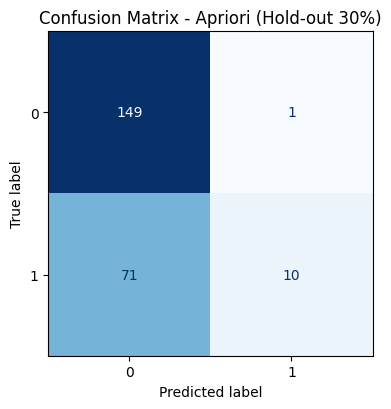


[+] Ma tran nham lan: FP-Growth (Hold-out 30%)
            Du doan: 0  Du doan: 1
Thuc te: 0         149           1
Thuc te: 1          71          10


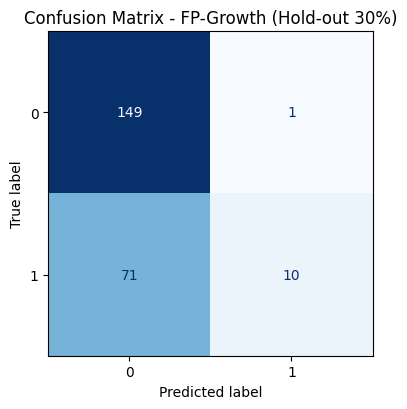


[+] Ma tran nham lan: ECLAT (Hold-out 30%)
            Du doan: 0  Du doan: 1
Thuc te: 0         149           1
Thuc te: 1          71          10


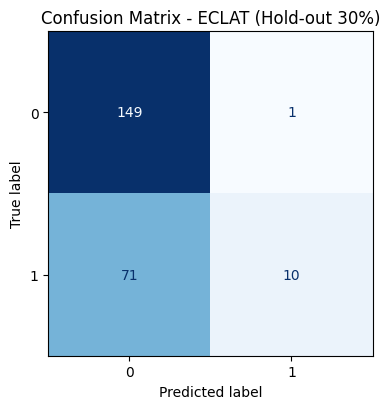


[+] Ma tran nham lan: Backprop_MLP (Hold-out 30%)
            Du doan: 0  Du doan: 1
Thuc te: 0         123          27
Thuc te: 1          37          44


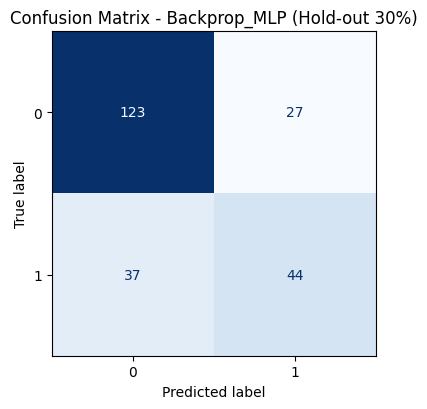


[+] Ma tran nham lan: TransferLearning_MLP (Hold-out 30%)
            Du doan: 0  Du doan: 1
Thuc te: 0         108          42
Thuc te: 1          19          62


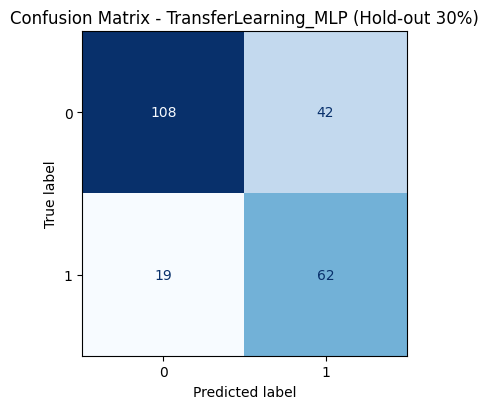

In [5]:
# 4) Hold-out 70/30
print("=" * 60)
print(f"BAT DAU HUAN LUYEN: TY LE {(1-TEST_SIZE)*100:.0f}/{TEST_SIZE*100:.0f}")
print("=" * 60)

results_list.clear()
roc_data.clear()

rule_methods = ["Apriori", "FP-Growth", "ECLAT"]

for method in rule_methods:
    y_pred, y_prob, _ = rule_based_train_predict(X_train, y_train, X_test, method)
    evaluate_and_record(y_test, y_pred, y_prob, f"Hold-out {int(TEST_SIZE*100)}%", method)

backprop_model = build_backprop_model()
backprop_model.fit(X_train, y_train)
y_pred_bp = backprop_model.predict(X_test)
y_prob_bp = backprop_model.predict_proba(X_test)[:, 1]
evaluate_and_record(y_test, y_pred_bp, y_prob_bp, f"Hold-out {int(TEST_SIZE*100)}%", "Backprop_MLP")

transfer_model = train_transfer_model(X_train, y_train)
y_pred_tl = transfer_model.predict(X_test)
y_prob_tl = transfer_model.predict_proba(X_test)[:, 1]
evaluate_and_record(y_test, y_pred_tl, y_prob_tl, f"Hold-out {int(TEST_SIZE*100)}%", "TransferLearning_MLP")

BAT DAU HUAN LUYEN: K-FOLD CROSS VALIDATION (K=10)

[+] Ma tran nham lan: Apriori (10-Fold CV)
            Du doan: 0  Du doan: 1
Thuc te: 0         492           8
Thuc te: 1         247          21


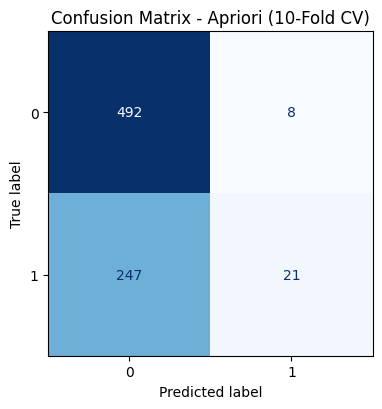


[+] Ma tran nham lan: FP-Growth (10-Fold CV)
            Du doan: 0  Du doan: 1
Thuc te: 0         492           8
Thuc te: 1         247          21


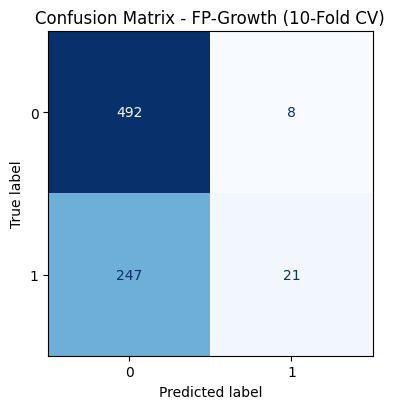


[+] Ma tran nham lan: ECLAT (10-Fold CV)
            Du doan: 0  Du doan: 1
Thuc te: 0         492           8
Thuc te: 1         247          21


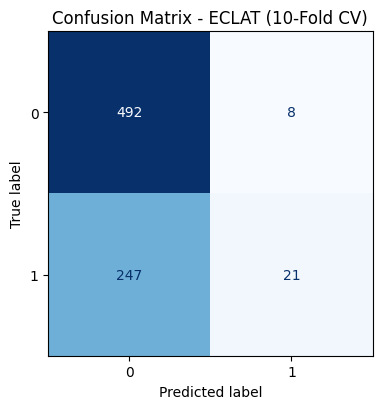


[+] Ma tran nham lan: Backprop_MLP (10-Fold CV)
            Du doan: 0  Du doan: 1
Thuc te: 0         406          94
Thuc te: 1         111         157


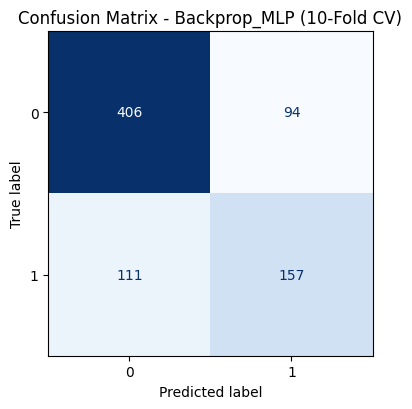


[+] Ma tran nham lan: TransferLearning_MLP (10-Fold CV)
            Du doan: 0  Du doan: 1
Thuc te: 0         347         153
Thuc te: 1          70         198


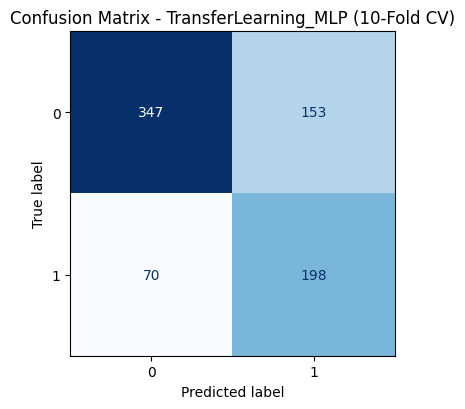

In [6]:
# 5) K-Fold Cross Validation (K=10)
print("=" * 60)
print(f"BAT DAU HUAN LUYEN: K-FOLD CROSS VALIDATION (K={K_FOLDS})")
print("=" * 60)

cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Rule-based models
for method in rule_methods:
    y_pred_oof = np.zeros(len(y), dtype=int)
    y_prob_oof = np.zeros(len(y), dtype=float)

    for tr_idx, te_idx in cv.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr = y.iloc[tr_idx]
        pred_fold, prob_fold, _ = rule_based_train_predict(X_tr, y_tr, X_te, method)
        y_pred_oof[te_idx] = pred_fold
        y_prob_oof[te_idx] = prob_fold

    evaluate_and_record(y, y_pred_oof, y_prob_oof, f"{K_FOLDS}-Fold CV", method)

# Backpropagation model
y_pred_bp_oof = np.zeros(len(y), dtype=int)
y_prob_bp_oof = np.zeros(len(y), dtype=float)
for tr_idx, te_idx in cv.split(X, y):
    model_bp = build_backprop_model()
    model_bp.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    y_pred_bp_oof[te_idx] = model_bp.predict(X.iloc[te_idx])
    y_prob_bp_oof[te_idx] = model_bp.predict_proba(X.iloc[te_idx])[:, 1]
evaluate_and_record(y, y_pred_bp_oof, y_prob_bp_oof, f"{K_FOLDS}-Fold CV", "Backprop_MLP")

# Transfer learning model
y_pred_tl_oof = np.zeros(len(y), dtype=int)
y_prob_tl_oof = np.zeros(len(y), dtype=float)
for tr_idx, te_idx in cv.split(X, y):
    model_tl = train_transfer_model(X.iloc[tr_idx], y.iloc[tr_idx])
    y_pred_tl_oof[te_idx] = model_tl.predict(X.iloc[te_idx])
    y_prob_tl_oof[te_idx] = model_tl.predict_proba(X.iloc[te_idx])[:, 1]
evaluate_and_record(y, y_pred_tl_oof, y_prob_tl_oof, f"{K_FOLDS}-Fold CV", "TransferLearning_MLP")

BANG TONG HOP CAC CHI SO DANH GIA MO HINH
      Method                Model  Accuracy  Precision  Recall  F1-Score    AUC
Hold-out 30% TransferLearning_MLP    0.7359     0.5962  0.7654    0.6703 0.8040
Hold-out 30%         Backprop_MLP    0.7229     0.6197  0.5432    0.5789 0.7797
Hold-out 30%              Apriori    0.6883     0.9091  0.1235    0.2174 0.8165
Hold-out 30%            FP-Growth    0.6883     0.9091  0.1235    0.2174 0.8165
Hold-out 30%                ECLAT    0.6883     0.9091  0.1235    0.2174 0.8165
  10-Fold CV TransferLearning_MLP    0.7096     0.5641  0.7388    0.6397 0.8004
  10-Fold CV         Backprop_MLP    0.7331     0.6255  0.5858    0.6050 0.7753
  10-Fold CV              Apriori    0.6680     0.7241  0.0784    0.1414 0.7956
  10-Fold CV            FP-Growth    0.6680     0.7241  0.0784    0.1414 0.7956
  10-Fold CV                ECLAT    0.6680     0.7241  0.0784    0.1414 0.7956


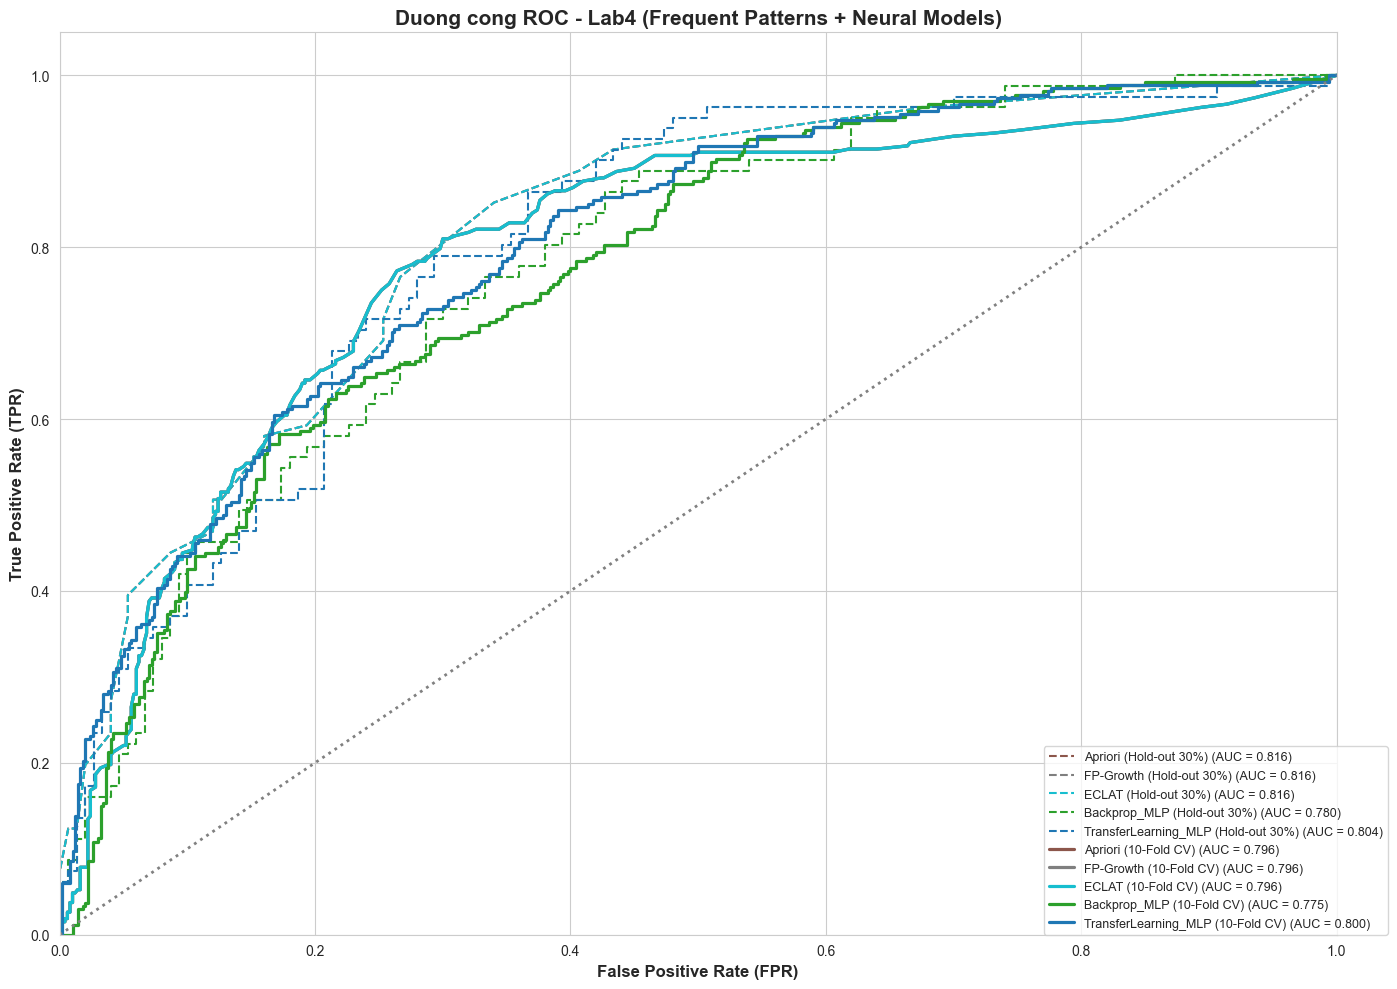

In [7]:
# 6) Bang tong hop ket qua + ROC
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by=["Method", "F1-Score"], ascending=[False, False]).reset_index(drop=True)

print("=" * 90)
print("BANG TONG HOP CAC CHI SO DANH GIA MO HINH")
print("=" * 90)
print(results_df.round(4).to_string(index=False))

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

model_names = results_df["Model"].unique().tolist()
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(model_names)))
model_color_map = {model_names[i]: colors[i] for i in range(len(model_names))}

for key, (fpr, tpr, roc_auc) in roc_data.items():
    model_name, method_name = key.split(" (")
    linestyle = "--" if "Hold-out" in method_name else "-"
    linewidth = 2.3 if "CV" in method_name else 1.5
    plt.plot(
        fpr, tpr,
        linestyle=linestyle,
        lw=linewidth,
        color=model_color_map.get(model_name, "black"),
        label=f"{key} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle=":")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight="bold")
plt.title("Duong cong ROC - Lab4 (Frequent Patterns + Neural Models)", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=9, bbox_to_anchor=(1.04, 0), borderaxespad=0.0)
plt.tight_layout()
plt.show()